# Reconocimiento inteligente de modulaciones digitales con DSP e IA

Este notebook unifica la explicacion teorica, la metodologia, el modelo de IA y los resultados experimentales del proyecto. La meta es clasificar modulaciones digitales a partir de senales IQ sinteticas usando rasgos DSP interpretables y un modelo MLP ligero.


In [1]:
from pathlib import Path
import json
import csv

try:
    from IPython.display import SVG, display
except Exception:
    class SVG(str):
        pass

    def display(value):
        print(str(value)[:1000])

ROOT = Path.cwd()
summary = json.loads((ROOT / "outputs" / "summary.json").read_text(encoding="utf-8"))
research_summary = json.loads((ROOT / "outputs" / "research" / "research_summary.json").read_text(encoding="utf-8"))
print(f"Accuracy base de prueba: {summary['test_accuracy'] * 100:.2f}%")
print(f"Baseline DSP: {research_summary['baseline_vs_ai'][0]['accuracy'] * 100:.2f}%")
print(f"MLP IA: {research_summary['baseline_vs_ai'][1]['accuracy'] * 100:.2f}%")
repeated = research_summary["repeated_trial_summary"]["ai_accuracy"]
print(f"MLP IA multisemilla: {repeated['mean'] * 100:.2f}% +/- {repeated['std'] * 100:.2f}%")
print("Features DSP: 36")
print("Parametros entrenables del MLP: 2070")


Accuracy base de prueba: 97.92%
Baseline DSP: 82.13%
MLP IA: 98.01%
MLP IA multisemilla: 98.28% +/- 0.86%
Features DSP: 36
Parametros entrenables del MLP: 2070


## 1. Problema y objetivo

En comunicaciones digitales, reconocer automaticamente la modulacion de una senal es util para monitoreo de espectro, radio cognitiva, diagnostico de enlaces y docencia. La pregunta central es si un modelo pequeno puede distinguir modulaciones sin hardware SDR ni datasets externos, usando solamente senales generadas por codigo y rasgos DSP.

**Objetivo general:** construir y evaluar un clasificador automatico de modulaciones digitales basado en senales IQ sinteticas, extraccion de rasgos DSP y aprendizaje supervisado.


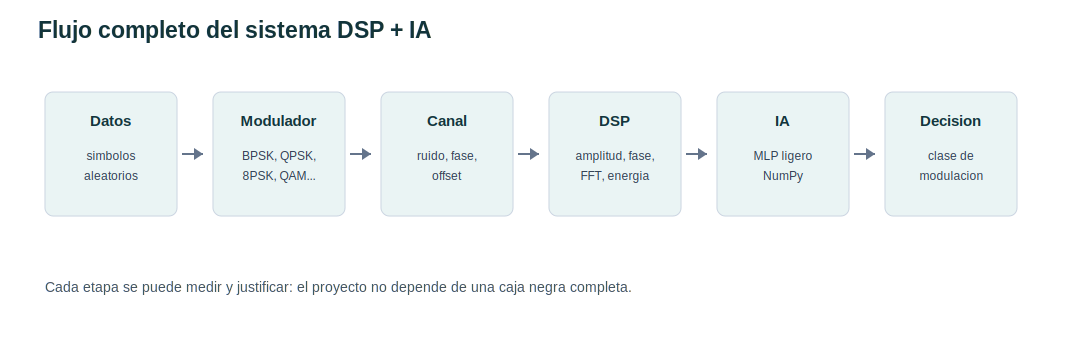

In [2]:
pipeline_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="1080" height="360" viewBox="0 0 1080 360" style="background:#ffffff"><title>Flujo del sistema</title><text x="38.0" y="38.0" font-family="Arial, sans-serif" font-size="23" font-weight="700" text-anchor="start" fill="#12343B">Flujo completo del sistema DSP + IA</text><rect x="45.0" y="92.0" width="132.0" height="124.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="111.0" y="126.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#12343B">Datos</text><text x="111.0" y="160.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">simbolos</text><text x="111.0" y="180.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">aleatorios</text><line x1="182.0" y1="154.0" x2="203.0" y2="154.0" stroke="#64748B" stroke-width="2"/><polygon points="203.0,154.0 194.0,148.0 194.0,160.0" fill="#64748B"/><rect x="213.0" y="92.0" width="132.0" height="124.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="279.0" y="126.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#12343B">Modulador</text><text x="279.0" y="160.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">BPSK, QPSK,</text><text x="279.0" y="180.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">8PSK, QAM...</text><line x1="350.0" y1="154.0" x2="371.0" y2="154.0" stroke="#64748B" stroke-width="2"/><polygon points="371.0,154.0 362.0,148.0 362.0,160.0" fill="#64748B"/><rect x="381.0" y="92.0" width="132.0" height="124.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="447.0" y="126.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#12343B">Canal</text><text x="447.0" y="160.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">ruido, fase,</text><text x="447.0" y="180.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">offset</text><line x1="518.0" y1="154.0" x2="539.0" y2="154.0" stroke="#64748B" stroke-width="2"/><polygon points="539.0,154.0 530.0,148.0 530.0,160.0" fill="#64748B"/><rect x="549.0" y="92.0" width="132.0" height="124.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="615.0" y="126.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#12343B">DSP</text><text x="615.0" y="160.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">amplitud, fase,</text><text x="615.0" y="180.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">FFT, energia</text><line x1="686.0" y1="154.0" x2="707.0" y2="154.0" stroke="#64748B" stroke-width="2"/><polygon points="707.0,154.0 698.0,148.0 698.0,160.0" fill="#64748B"/><rect x="717.0" y="92.0" width="132.0" height="124.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="783.0" y="126.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#12343B">IA</text><text x="783.0" y="160.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">MLP ligero</text><text x="783.0" y="180.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">NumPy</text><line x1="854.0" y1="154.0" x2="875.0" y2="154.0" stroke="#64748B" stroke-width="2"/><polygon points="875.0,154.0 866.0,148.0 866.0,160.0" fill="#64748B"/><rect x="885.0" y="92.0" width="132.0" height="124.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="951.0" y="126.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#12343B">Decision</text><text x="951.0" y="160.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">clase de</text><text x="951.0" y="180.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="middle" fill="#334155">modulacion</text><text x="45.0" y="292.0" font-family="Arial, sans-serif" font-size="14" font-weight="400" text-anchor="start" fill="#475569">Cada etapa se puede medir y justificar: el proyecto no depende de una caja negra completa.</text></svg>'
display(SVG(pipeline_svg))


## 2. Generacion de senales IQ

El proyecto simula seis modulaciones: BPSK, QPSK, 8PSK, 16QAM, 2FSK y 4ASK. Cada senal se genera como una secuencia de simbolos complejos I/Q, se sobremuestrea y luego se degrada con efectos de canal: ruido AWGN, fase aleatoria, desplazamiento de frecuencia, variacion de ganancia, Rayleigh y multipath.

La ventaja de esta estrategia es que el experimento es reproducible: cualquier resultado puede regenerarse desde los scripts del proyecto.


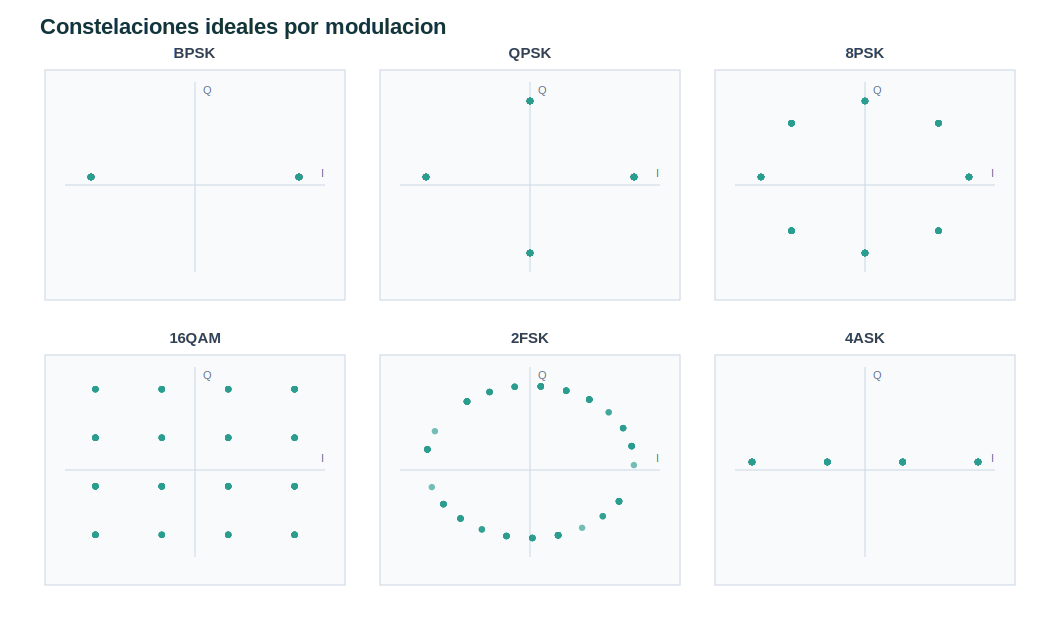

In [3]:
constellation_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="1040" height="620" viewBox="0 0 1040 620" style="background:#ffffff"><title>Constelaciones</title><text x="40.0" y="34.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Constelaciones ideales por modulacion</text><rect x="45.0" y="70.0" width="300.0" height="230.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="195.0" y1="82.0" x2="195.0" y2="272.0" stroke="#CBD5E1" stroke-width="1"/><line x1="65.0" y1="185.0" x2="325.0" y2="185.0" stroke="#CBD5E1" stroke-width="1"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="91.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="299.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><text x="195.0" y="58.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">BPSK</text><text x="321.0" y="177.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">I</text><text x="203.0" y="94.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">Q</text><rect x="380.0" y="70.0" width="300.0" height="230.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="530.0" y1="82.0" x2="530.0" y2="272.0" stroke="#CBD5E1" stroke-width="1"/><line x1="400.0" y1="185.0" x2="660.0" y2="185.0" stroke="#CBD5E1" stroke-width="1"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="426.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="634.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="530.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><text x="530.0" y="58.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">QPSK</text><text x="656.0" y="177.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">I</text><text x="538.0" y="94.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">Q</text><rect x="715.0" y="70.0" width="300.0" height="230.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="865.0" y1="82.0" x2="865.0" y2="272.0" stroke="#CBD5E1" stroke-width="1"/><line x1="735.0" y1="185.0" x2="995.0" y2="185.0" stroke="#CBD5E1" stroke-width="1"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="969.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="101.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="123.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="938.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="865.0" cy="253.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="791.5" cy="230.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="761.0" cy="177.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><text x="865.0" y="58.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">8PSK</text><text x="991.0" y="177.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">I</text><text x="873.0" y="94.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">Q</text><rect x="45.0" y="355.0" width="300.0" height="230.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="195.0" y1="367.0" x2="195.0" y2="557.0" stroke="#CBD5E1" stroke-width="1"/><line x1="65.0" y1="470.0" x2="325.0" y2="470.0" stroke="#CBD5E1" stroke-width="1"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="161.8" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="534.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="95.4" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="389.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="228.2" cy="437.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="294.6" cy="486.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><text x="195.0" y="343.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">16QAM</text><text x="321.0" y="462.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">I</text><text x="203.0" y="379.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">Q</text><rect x="380.0" y="355.0" width="300.0" height="230.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="530.0" y1="367.0" x2="530.0" y2="557.0" stroke="#CBD5E1" stroke-width="1"/><line x1="400.0" y1="470.0" x2="660.0" y2="470.0" stroke="#CBD5E1" stroke-width="1"/><circle cx="608.7" cy="412.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="481.9" cy="529.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="514.7" cy="386.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="514.7" cy="386.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="514.7" cy="386.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="582.1" cy="527.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="514.7" cy="386.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="514.7" cy="386.8" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="506.4" cy="536.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="589.3" cy="399.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="443.4" cy="504.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="631.7" cy="446.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="427.4" cy="449.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="619.0" cy="501.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="467.0" cy="401.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="558.1" cy="535.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="481.9" cy="529.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="540.8" cy="386.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="481.9" cy="529.4" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="608.7" cy="412.3" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="431.8" cy="487.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="633.9" cy="465.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="434.9" cy="431.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="602.8" cy="516.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="489.6" cy="392.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="489.6" cy="392.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="602.8" cy="516.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="489.6" cy="392.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="623.1" cy="428.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="489.6" cy="392.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="489.6" cy="392.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="602.8" cy="516.2" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="489.6" cy="392.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="489.6" cy="392.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="532.3" cy="538.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="566.2" cy="390.7" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="623.1" cy="428.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="623.1" cy="428.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="623.1" cy="428.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="460.5" cy="518.5" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="623.1" cy="428.1" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><text x="530.0" y="343.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">2FSK</text><text x="656.0" y="462.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">I</text><text x="538.0" y="379.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">Q</text><rect x="715.0" y="355.0" width="300.0" height="230.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="865.0" y1="367.0" x2="865.0" y2="557.0" stroke="#CBD5E1" stroke-width="1"/><line x1="735.0" y1="470.0" x2="995.0" y2="470.0" stroke="#CBD5E1" stroke-width="1"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="978.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="827.3" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="902.7" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><circle cx="752.0" cy="462.0" r="3.2" fill="#2A9D8F" fill-opacity="0.65"/><text x="865.0" y="343.0" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">4ASK</text><text x="991.0" y="462.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">I</text><text x="873.0" y="379.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="start" fill="#64748B">Q</text></svg>'
display(SVG(constellation_svg))


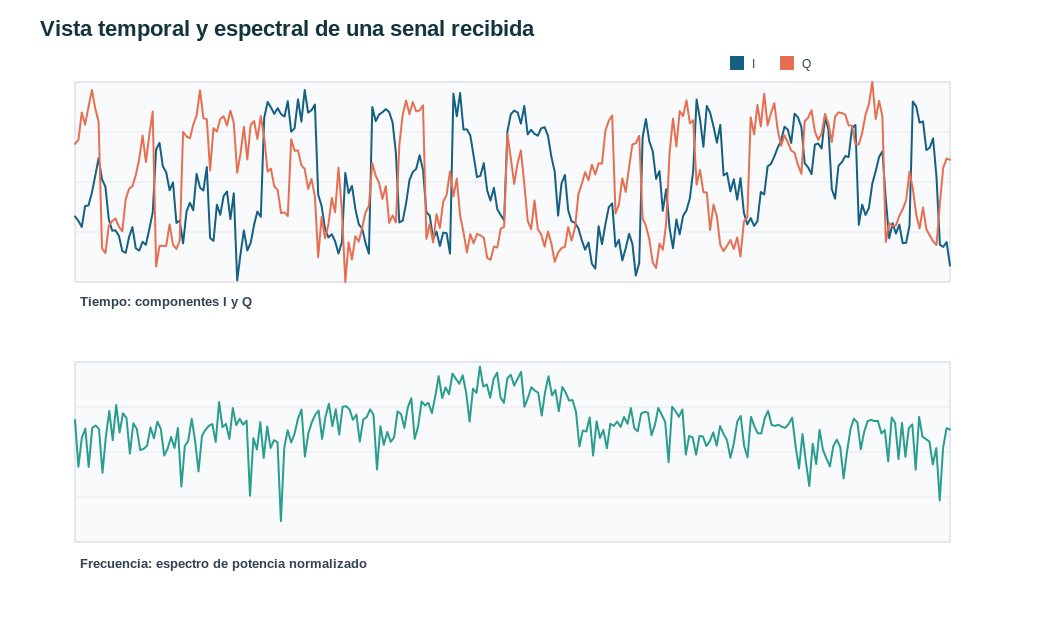

In [4]:
iq_spectrum_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="1040" height="620" viewBox="0 0 1040 620" style="background:#ffffff"><title>Tiempo y espectro</title><text x="40.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Vista temporal y espectral de una senal recibida</text><rect x="75.0" y="82.0" width="875.0" height="200.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="75.0" y1="82.0" x2="950.0" y2="82.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="132.0" x2="950.0" y2="132.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="182.0" x2="950.0" y2="182.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="232.0" x2="950.0" y2="232.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="282.0" x2="950.0" y2="282.0" stroke="#E5E7EB" stroke-width="1"/><polyline points="75.0,216.5 78.4,220.9 81.8,227.0 85.1,206.0 88.5,205.4 91.9,192.7 95.3,175.5 98.6,158.1 102.0,179.3 105.4,186.7 108.8,219.4 112.2,230.6 115.5,230.4 118.9,235.9 122.3,251.0 125.7,252.8 129.1,237.0 132.4,227.1 135.8,248.4 139.2,250.6 142.6,241.8 145.9,244.8 149.3,229.1 152.7,212.6 156.1,149.4 159.5,142.9 162.8,166.1 166.2,172.3 169.6,190.2 173.0,182.4 176.4,222.9 179.7,220.6 183.1,243.4 186.5,211.6 189.9,202.8 193.2,210.2 196.6,173.9 200.0,187.6 203.4,190.5 206.8,167.0 210.1,238.1 213.5,240.9 216.9,204.7 220.3,214.8 223.6,196.1 227.0,191.4 230.4,219.2 233.8,193.3 237.2,280.4 240.5,254.2 243.9,230.5 247.3,250.5 250.7,242.8 254.1,224.7 257.4,211.5 260.8,216.9 264.2,117.9 267.6,102.0 270.9,107.3 274.3,113.9 277.7,108.2 281.1,114.2 284.5,116.6 287.8,101.2 291.2,131.7 294.6,128.2 298.0,99.4 301.4,121.6 304.7,89.9 308.1,112.6 311.5,110.2 314.9,104.6 318.2,194.6 321.6,206.0 325.0,228.5 328.4,237.4 331.8,234.3 335.1,241.2 338.5,253.5 341.9,242.1 345.3,173.0 348.6,193.2 352.0,185.9 355.4,209.1 358.8,224.4 362.2,228.6 365.5,242.9 368.9,253.6 372.3,107.0 375.7,121.1 379.1,114.6 382.4,112.3 385.8,109.1 389.2,112.1 392.6,122.5 395.9,153.2 399.3,222.4 402.7,220.7 406.1,203.3 409.5,180.0 412.8,172.0 416.2,168.9 419.6,155.3 423.0,169.9 426.4,212.4 429.7,215.4 433.1,238.9 436.5,231.6 439.9,246.0 443.2,232.6 446.6,233.2 450.0,253.6 453.4,93.6 456.8,116.3 460.1,93.0 463.5,129.5 466.9,129.4 470.3,135.4 473.6,155.8 477.0,177.1 480.4,175.8 483.8,163.1 487.2,190.5 490.5,200.6 493.9,187.8 497.3,209.3 500.7,215.0 504.1,220.5 507.4,131.5 510.8,114.2 514.2,110.6 517.6,112.5 520.9,123.6 524.3,105.9 527.7,134.4 531.1,129.8 534.5,133.8 537.8,135.7 541.2,128.3 544.6,127.2 548.0,135.8 551.4,156.9 554.7,171.6 558.1,215.6 561.5,183.5 564.9,174.9 568.2,210.4 571.6,221.3 575.0,222.8 578.4,228.4 581.8,240.2 585.1,249.7 588.5,242.5 591.9,263.7 595.3,268.6 598.6,226.3 602.0,244.2 605.4,224.3 608.8,207.2 612.2,203.4 615.5,246.6 618.9,239.8 622.3,260.4 625.7,248.4 629.1,233.8 632.4,244.0 635.8,275.5 639.2,263.1 642.6,137.7 645.9,119.1 649.3,141.3 652.7,151.2 656.1,178.8 659.5,171.1 662.8,210.8 666.2,189.2 669.6,228.3 673.0,248.2 676.4,219.4 679.7,234.4 683.1,215.8 686.5,210.4 689.9,198.1 693.2,170.7 696.6,99.5 700.0,119.2 703.4,146.8 706.8,106.0 710.1,112.7 713.5,126.4 716.9,142.7 720.3,124.9 723.6,175.4 727.0,173.0 730.4,191.4 733.8,179.3 737.2,199.7 740.5,178.1 743.9,212.8 747.3,224.4 750.7,218.1 754.1,225.9 757.4,221.3 760.8,192.0 764.2,194.5 767.6,166.4 770.9,164.0 774.3,156.6 777.7,147.7 781.1,140.7 784.5,126.7 787.8,129.6 791.2,142.9 794.6,113.7 798.0,117.4 801.4,127.1 804.7,163.3 808.1,167.3 811.5,174.1 814.9,144.6 818.2,143.5 821.6,148.5 825.0,117.8 828.4,129.3 831.8,189.1 835.1,198.7 838.5,165.7 841.9,162.2 845.3,156.0 848.6,157.1 852.0,128.1 855.4,125.0 858.8,224.8 862.2,204.7 865.5,214.9 868.9,208.1 872.3,183.5 875.7,171.2 879.1,156.8 882.4,151.4 885.8,199.2 889.2,238.3 892.6,223.1 895.9,233.5 899.3,224.6 902.7,243.1 906.1,242.8 909.5,225.7 912.8,101.6 916.2,106.4 919.6,122.6 923.0,121.5 926.4,150.0 929.7,147.8 933.1,138.4 936.5,177.3 939.9,244.8 943.2,246.9 946.6,242.0 950.0,265.5" fill="none" stroke="#156082" stroke-width="2" stroke-linejoin="round" stroke-linecap="round"/><polyline points="75.0,143.9 78.4,140.0 81.8,112.5 85.1,124.6 88.5,106.8 91.9,90.0 95.3,108.7 98.6,121.6 102.0,248.3 105.4,253.1 108.8,225.7 112.2,221.1 115.5,218.5 118.9,226.7 122.3,231.3 125.7,199.2 129.1,188.7 132.4,186.3 135.8,175.2 139.2,159.0 142.6,135.5 145.9,162.0 149.3,135.0 152.7,111.5 156.1,266.6 159.5,245.9 162.8,245.9 166.2,245.9 169.6,224.4 173.0,244.6 176.4,249.0 179.7,240.9 183.1,131.9 186.5,136.5 189.9,138.3 193.2,124.8 196.6,115.4 200.0,90.3 203.4,118.2 206.8,119.3 210.1,170.5 213.5,128.2 216.9,131.5 220.3,118.7 223.6,116.3 227.0,125.6 230.4,110.7 233.8,123.0 237.2,172.7 240.5,153.7 243.9,126.8 247.3,159.5 250.7,124.8 254.1,121.1 257.4,139.0 260.8,116.2 264.2,137.5 267.6,171.6 270.9,168.7 274.3,186.3 277.7,190.2 281.1,213.2 284.5,212.4 287.8,216.1 291.2,139.2 294.6,150.8 298.0,150.5 301.4,165.4 304.7,168.9 308.1,188.8 311.5,178.9 314.9,196.5 318.2,257.1 321.6,216.9 325.0,238.3 328.4,224.6 331.8,197.9 335.1,212.2 338.5,167.6 341.9,210.8 345.3,282.0 348.6,242.4 352.0,259.4 355.4,236.3 358.8,241.6 362.2,227.8 365.5,212.5 368.9,205.8 372.3,163.1 375.7,175.8 379.1,182.9 382.4,198.9 385.8,186.1 389.2,222.9 392.6,215.4 395.9,222.5 399.3,145.6 402.7,114.6 406.1,100.5 409.5,114.2 412.8,102.1 416.2,111.4 419.6,110.4 423.0,105.3 426.4,238.9 429.7,224.0 433.1,242.5 436.5,214.2 439.9,227.9 443.2,201.7 446.6,194.9 450.0,171.3 453.4,196.4 456.8,178.5 460.1,215.4 463.5,232.2 466.9,252.4 470.3,234.1 473.6,243.3 477.0,234.0 480.4,235.4 483.8,237.8 487.2,257.9 490.5,259.9 493.9,246.5 497.3,247.6 500.7,228.8 504.1,226.8 507.4,133.9 510.8,158.1 514.2,183.9 517.6,163.1 520.9,150.4 524.3,184.2 527.7,220.8 531.1,229.3 534.5,200.4 537.8,229.2 541.2,234.3 544.6,246.6 548.0,231.5 551.4,243.6 554.7,261.8 558.1,252.7 561.5,248.1 564.9,246.9 568.2,227.1 571.6,240.5 575.0,227.8 578.4,194.2 581.8,183.9 585.1,172.2 588.5,180.1 591.9,164.7 595.3,174.4 598.6,163.4 602.0,163.6 605.4,130.9 608.8,120.6 612.2,115.5 615.5,213.4 618.9,204.5 622.3,178.3 625.7,191.9 629.1,166.9 632.4,144.4 635.8,143.3 639.2,135.8 642.6,218.3 645.9,225.9 649.3,239.2 652.7,262.5 656.1,267.9 659.5,243.6 662.8,249.8 666.2,223.4 669.6,152.4 673.0,118.6 676.4,146.4 679.7,111.1 683.1,116.1 686.5,100.4 689.9,123.4 693.2,120.3 696.6,184.6 700.0,170.0 703.4,192.2 706.8,192.5 710.1,230.0 713.5,204.6 716.9,216.5 720.3,245.1 723.6,251.1 727.0,245.9 730.4,240.0 733.8,249.0 737.2,237.5 740.5,256.5 743.9,221.6 747.3,217.5 750.7,117.3 754.1,134.4 757.4,104.9 760.8,126.5 764.2,93.9 767.6,125.4 770.9,113.4 774.3,103.1 777.7,129.8 781.1,145.6 784.5,135.2 787.8,142.3 791.2,150.6 794.6,152.8 798.0,165.1 801.4,173.7 804.7,121.2 808.1,117.7 811.5,110.3 814.9,131.5 818.2,139.9 821.6,133.7 825.0,113.9 828.4,123.6 831.8,142.0 835.1,116.6 838.5,112.4 841.9,113.1 845.3,114.6 848.6,125.3 852.0,125.7 855.4,143.9 858.8,144.4 862.2,132.7 865.5,114.9 868.9,104.2 872.3,82.0 875.7,119.1 879.1,100.7 882.4,116.5 885.8,242.0 889.2,223.2 892.6,226.0 895.9,225.4 899.3,215.9 902.7,209.3 906.1,200.5 909.5,171.6 912.8,188.4 916.2,214.5 919.6,228.5 923.0,207.5 926.4,229.3 929.7,235.4 933.1,241.3 936.5,245.0 939.9,203.2 943.2,167.8 946.6,158.5 950.0,159.8" fill="none" stroke="#E76F51" stroke-width="2" stroke-linejoin="round" stroke-linecap="round"/><text x="80.0" y="306.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="start" fill="#334155">Tiempo: componentes I y Q</text><rect x="730.0" y="56.0" width="14.0" height="14.0" rx="0" fill="#156082" stroke="none"/><text x="752.0" y="68.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">I</text><rect x="780.0" y="56.0" width="14.0" height="14.0" rx="0" fill="#E76F51" stroke="none"/><text x="802.0" y="68.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Q</text><rect x="75.0" y="362.0" width="875.0" height="180.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="75.0" y1="362.0" x2="950.0" y2="362.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="407.0" x2="950.0" y2="407.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="452.0" x2="950.0" y2="452.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="497.0" x2="950.0" y2="497.0" stroke="#E5E7EB" stroke-width="1"/><line x1="75.0" y1="542.0" x2="950.0" y2="542.0" stroke="#E5E7EB" stroke-width="1"/><polyline points="75.0,419.9 78.4,466.7 81.9,437.6 85.3,428.6 88.7,466.9 92.2,428.0 95.6,425.5 99.0,429.0 102.5,472.8 105.9,436.3 109.3,411.0 112.7,440.2 116.2,405.0 119.6,432.5 123.0,413.3 126.5,418.2 129.9,453.7 133.3,423.3 136.8,429.0 140.2,450.0 143.6,448.9 147.1,445.7 150.5,427.3 153.9,438.4 157.4,421.7 160.8,428.8 164.2,455.5 167.6,448.7 171.1,437.0 174.5,447.9 177.9,428.0 181.4,486.6 184.8,446.1 188.2,440.9 191.7,418.8 195.1,440.8 198.5,471.4 202.0,435.7 205.4,429.9 208.8,425.8 212.3,424.0 215.7,441.9 219.1,402.1 222.5,427.1 226.0,423.9 229.4,438.9 232.8,408.1 236.3,425.1 239.7,418.7 243.1,424.7 246.6,420.6 250.0,495.7 253.4,438.1 256.9,449.4 260.3,422.2 263.7,457.9 267.2,426.5 270.6,448.0 274.0,440.2 277.5,442.2 280.9,521.1 284.3,447.2 287.7,430.3 291.2,442.5 294.6,433.5 298.0,418.6 301.5,409.5 304.9,456.6 308.3,433.5 311.8,422.3 315.2,414.9 318.6,410.6 322.1,438.9 325.5,416.6 328.9,403.8 332.4,426.2 335.8,409.3 339.2,434.6 342.6,406.8 346.1,406.2 349.5,409.2 352.9,419.8 356.4,414.6 359.8,441.7 363.2,419.6 366.7,417.1 370.1,409.4 373.5,414.7 377.0,469.5 380.4,426.3 383.8,444.8 387.3,432.0 390.7,441.9 394.1,437.4 397.5,411.4 401.0,414.0 404.4,427.8 407.8,407.4 411.3,398.3 414.7,438.8 418.1,426.5 421.6,401.5 425.0,405.5 428.4,402.8 431.9,413.1 435.3,396.1 438.7,376.1 442.2,398.0 445.6,387.4 449.0,394.2 452.5,373.7 455.9,378.8 459.3,383.8 462.7,375.3 466.2,392.7 469.6,421.6 473.0,388.7 476.5,392.9 479.9,366.6 483.3,386.5 486.8,384.5 490.2,397.7 493.6,379.0 497.1,372.7 500.5,397.3 503.9,402.9 507.4,378.2 510.8,374.8 514.2,385.6 517.6,378.8 521.1,372.0 524.5,406.8 527.9,397.9 531.4,387.2 534.8,390.6 538.2,392.6 541.7,415.5 545.1,391.9 548.5,376.3 552.0,395.4 555.4,390.0 558.8,411.2 562.3,387.0 565.7,392.6 569.1,400.6 572.5,400.0 576.0,411.9 579.4,446.4 582.8,430.5 586.3,431.6 589.7,417.4 593.1,455.6 596.6,421.4 600.0,438.0 603.4,429.9 606.9,448.3 610.3,423.8 613.7,425.9 617.2,421.6 620.6,426.9 624.0,417.0 627.5,423.8 630.9,408.1 634.3,428.3 637.7,431.3 641.2,413.5 644.6,411.9 648.0,412.6 651.5,435.4 654.9,425.0 658.3,408.0 661.8,414.9 665.2,421.9 668.6,462.2 672.1,406.8 675.5,411.1 678.9,416.8 682.4,409.5 685.8,454.6 689.2,435.9 692.6,437.4 696.1,454.7 699.5,435.9 702.9,436.5 706.4,446.1 709.8,441.2 713.2,432.4 716.7,445.7 720.1,426.1 723.5,433.9 727.0,440.2 730.4,457.8 733.8,443.5 737.3,421.5 740.7,416.0 744.1,445.8 747.5,457.4 751.0,416.8 754.4,426.4 757.8,433.3 761.3,433.4 764.7,418.4 768.1,410.9 771.6,424.9 775.0,425.9 778.4,424.7 781.9,426.9 785.3,427.8 788.7,423.9 792.2,417.7 795.6,446.3 799.0,468.5 802.5,434.0 805.9,461.8 809.3,486.0 812.7,443.7 816.2,464.1 819.6,429.9 823.0,450.1 826.5,458.6 829.9,466.4 833.3,446.2 836.8,439.7 840.2,446.8 843.6,478.4 847.1,451.1 850.5,429.0 853.9,418.7 857.4,422.6 860.8,449.3 864.2,431.7 867.6,421.2 871.1,419.9 874.5,421.1 877.9,420.8 881.4,433.4 884.8,430.1 888.2,461.4 891.7,417.5 895.1,423.0 898.5,459.0 902.0,422.8 905.4,456.8 908.8,428.1 912.3,424.4 915.7,469.6 919.1,416.9 922.5,436.8 926.0,439.1 929.4,441.6 932.8,464.4 936.3,448.1 939.7,500.4 943.1,447.7 946.6,428.2 950.0,429.5" fill="none" stroke="#2A9D8F" stroke-width="2" stroke-linejoin="round" stroke-linecap="round"/><text x="80.0" y="568.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="start" fill="#334155">Frecuencia: espectro de potencia normalizado</text></svg>'
display(SVG(iq_spectrum_svg))


## 3. Extraccion de rasgos DSP

Antes de usar IA, cada senal se transforma en un vector numerico compacto. El sistema calcula 36 rasgos agrupados en amplitud, componentes I/Q, fase y espectro. Esto hace que el modelo no trabaje con muestras crudas, sino con mediciones fisicas de la senal.

Ejemplos de rasgos:

- media, desviacion y percentiles de amplitud;
- PAPR o relacion pico-promedio;
- desviacion de diferencias de fase;
- correlaciones de fase con retardos;
- entropia espectral, centroide, ancho de banda efectivo y energia central.


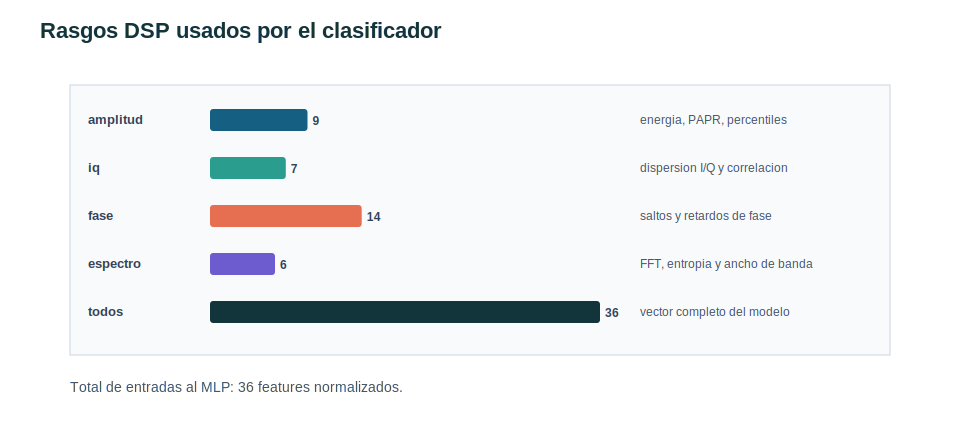

In [5]:
feature_groups_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="960" height="430" viewBox="0 0 960 430" style="background:#ffffff"><title>Features DSP</title><text x="40.0" y="38.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Rasgos DSP usados por el clasificador</text><rect x="70.0" y="85.0" width="820.0" height="270.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><text x="88.0" y="124.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="start" fill="#334155">amplitud</text><rect x="210.0" y="109.0" width="97.5" height="22.0" rx="3" fill="#156082" stroke="none"/><text x="312.5" y="125.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="start" fill="#334155"> 9</text><text x="640.0" y="124.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#475569">energia, PAPR, percentiles</text><text x="88.0" y="172.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="start" fill="#334155">iq</text><rect x="210.0" y="157.0" width="75.8" height="22.0" rx="3" fill="#2A9D8F" stroke="none"/><text x="290.8" y="173.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="start" fill="#334155"> 7</text><text x="640.0" y="172.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#475569">dispersion I/Q y correlacion</text><text x="88.0" y="220.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="start" fill="#334155">fase</text><rect x="210.0" y="205.0" width="151.7" height="22.0" rx="3" fill="#E76F51" stroke="none"/><text x="366.7" y="221.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="start" fill="#334155"> 14</text><text x="640.0" y="220.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#475569">saltos y retardos de fase</text><text x="88.0" y="268.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="start" fill="#334155">espectro</text><rect x="210.0" y="253.0" width="65.0" height="22.0" rx="3" fill="#6D5BD0" stroke="none"/><text x="280.0" y="269.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="start" fill="#334155"> 6</text><text x="640.0" y="268.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#475569">FFT, entropia y ancho de banda</text><text x="88.0" y="316.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="start" fill="#334155">todos</text><rect x="210.0" y="301.0" width="390.0" height="22.0" rx="3" fill="#12343B" stroke="none"/><text x="605.0" y="317.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="start" fill="#334155"> 36</text><text x="640.0" y="316.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#475569">vector completo del modelo</text><text x="70.0" y="392.0" font-family="Arial, sans-serif" font-size="14" font-weight="400" text-anchor="start" fill="#475569">Total de entradas al MLP: 36 features normalizados.</text></svg>'
display(SVG(feature_groups_svg))


## 4. Modelo de IA: MLP ligero en NumPy

El clasificador principal es una red neuronal multicapa implementada desde cero con NumPy. Su entrada es un vector de **36 rasgos DSP normalizados** y su salida es una distribucion de probabilidad sobre las **6 modulaciones**.

Arquitectura usada:

- Entrada: 36 features DSP.
- Capa oculta: 48 neuronas con activacion ReLU.
- Salida: 6 neuronas con softmax.
- Parametros entrenables: 2070.

Flujo matematico:

`z = (x - media) / desviacion`

`h = ReLU(zW1 + b1)`

`logits = hW2 + b2`

`p(clase | x) = softmax(logits)`

La funcion de perdida es entropia cruzada, con regularizacion L2 para reducir sobreajuste. Se entrena con mini-batches y descenso por gradiente.


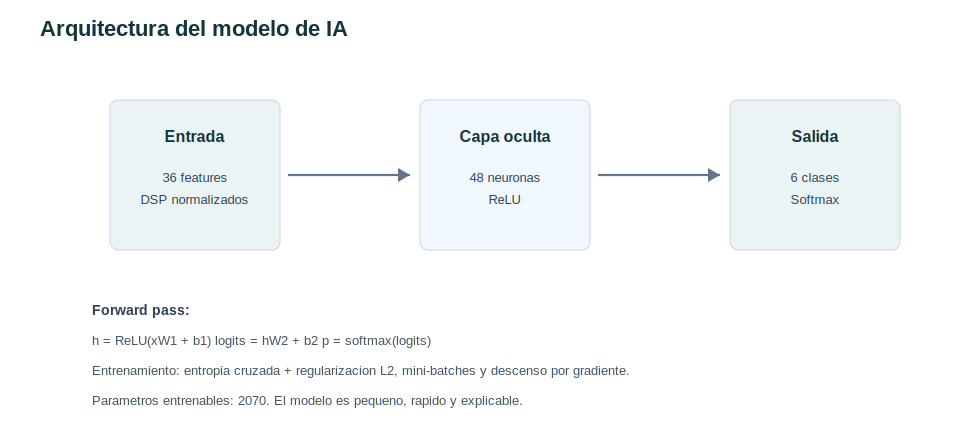

In [6]:
model_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="980" height="440" viewBox="0 0 980 440" style="background:#ffffff"><title>Modelo MLP</title><text x="40.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Arquitectura del modelo de IA</text><rect x="110.0" y="100.0" width="170.0" height="150.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="195.0" y="142.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#12343B">Entrada</text><text x="195.0" y="182.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="middle" fill="#334155">36 features</text><text x="195.0" y="204.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="middle" fill="#334155">DSP normalizados</text><line x1="288.0" y1="175.0" x2="410.0" y2="175.0" stroke="#64748B" stroke-width="2.2"/><polygon points="410.0,175 398.0,168 398.0,182" fill="#64748B"/><rect x="420.0" y="100.0" width="170.0" height="150.0" rx="8" fill="#F0F7FF" stroke="#CBD5E1"/><text x="505.0" y="142.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#12343B">Capa oculta</text><text x="505.0" y="182.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="middle" fill="#334155">48 neuronas</text><text x="505.0" y="204.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="middle" fill="#334155">ReLU</text><line x1="598.0" y1="175.0" x2="720.0" y2="175.0" stroke="#64748B" stroke-width="2.2"/><polygon points="720.0,175 708.0,168 708.0,182" fill="#64748B"/><rect x="730.0" y="100.0" width="170.0" height="150.0" rx="8" fill="#EAF4F4" stroke="#CBD5E1"/><text x="815.0" y="142.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#12343B">Salida</text><text x="815.0" y="182.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="middle" fill="#334155">6 clases</text><text x="815.0" y="204.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="middle" fill="#334155">Softmax</text><text x="92.0" y="315.0" font-family="Arial, sans-serif" font-size="14" font-weight="700" text-anchor="start" fill="#334155">Forward pass:</text><text x="92.0" y="345.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">h = ReLU(xW1 + b1)    logits = hW2 + b2    p = softmax(logits)</text><text x="92.0" y="375.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">Entrenamiento: entropia cruzada + regularizacion L2, mini-batches y descenso por gradiente.</text><text x="92.0" y="405.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">Parametros entrenables: 2070. El modelo es pequeno, rapido y explicable.</text></svg>'
display(SVG(model_svg))


## 5. Experimento base

El experimento base separa los datos en entrenamiento y prueba, normaliza los rasgos usando solo el conjunto de entrenamiento, entrena el MLP y evalua la matriz de confusion. Esta parte responde: "el sistema clasifica bien cuando entrenamiento y prueba vienen del mismo tipo de canal simulado?"


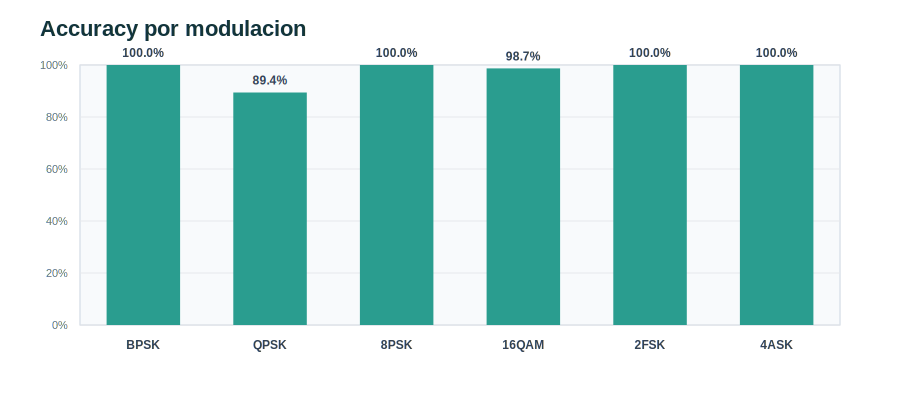

In [7]:
accuracy_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="900" height="420" viewBox="0 0 900 420" style="background:#ffffff"><title>Accuracy por clase</title><text x="40.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Accuracy por modulacion</text><rect x="80.0" y="65.0" width="760.0" height="260.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="80.0" y1="325.0" x2="840.0" y2="325.0" stroke="#E5E7EB" stroke-width="1"/><text x="68.0" y="329.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="80.0" y1="273.0" x2="840.0" y2="273.0" stroke="#E5E7EB" stroke-width="1"/><text x="68.0" y="277.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="80.0" y1="221.0" x2="840.0" y2="221.0" stroke="#E5E7EB" stroke-width="1"/><text x="68.0" y="225.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="80.0" y1="169.0" x2="840.0" y2="169.0" stroke="#E5E7EB" stroke-width="1"/><text x="68.0" y="173.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="80.0" y1="117.0" x2="840.0" y2="117.0" stroke="#E5E7EB" stroke-width="1"/><text x="68.0" y="121.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="80.0" y1="65.0" x2="840.0" y2="65.0" stroke="#E5E7EB" stroke-width="1"/><text x="68.0" y="69.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><rect x="106.6" y="65.0" width="73.5" height="260.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="143.3" y="57.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">100.0%</text><text x="143.3" y="349.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">BPSK</text><rect x="233.3" y="92.5" width="73.5" height="232.5" rx="0" fill="#2A9D8F" stroke="none"/><text x="270.0" y="84.5" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">89.4%</text><text x="270.0" y="349.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">QPSK</text><rect x="359.9" y="65.0" width="73.5" height="260.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="396.7" y="57.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">100.0%</text><text x="396.7" y="349.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">8PSK</text><rect x="486.6" y="68.4" width="73.5" height="256.6" rx="0" fill="#2A9D8F" stroke="none"/><text x="523.3" y="60.4" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">98.7%</text><text x="523.3" y="349.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">16QAM</text><rect x="613.3" y="65.0" width="73.5" height="260.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="650.0" y="57.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">100.0%</text><text x="650.0" y="349.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">2FSK</text><rect x="739.9" y="65.0" width="73.5" height="260.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="776.7" y="57.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">100.0%</text><text x="776.7" y="349.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">4ASK</text></svg>'
display(SVG(accuracy_svg))


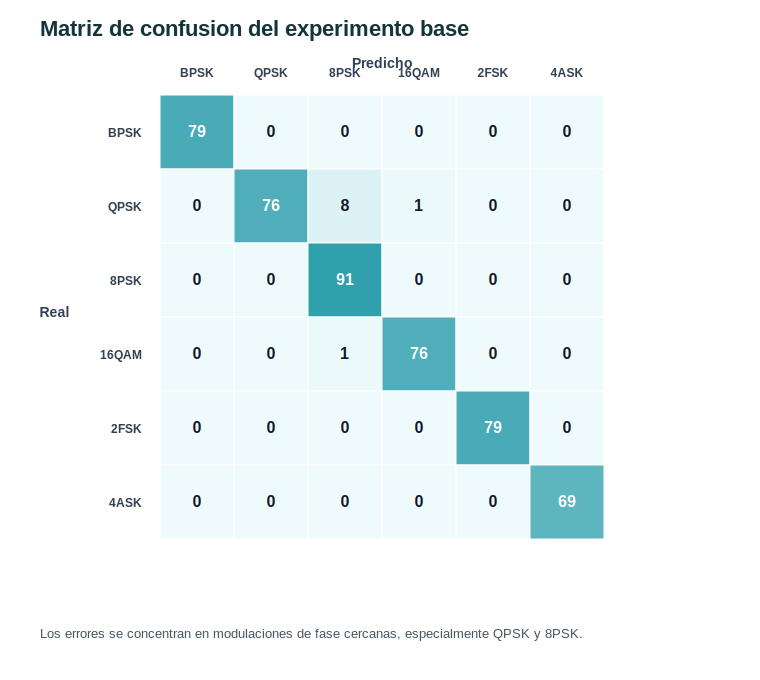

In [8]:
confusion_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="760" height="680" viewBox="0 0 760 680" style="background:#ffffff"><title>Matriz de confusion</title><text x="40.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Matriz de confusion del experimento base</text><text x="382.0" y="68.0" font-family="Arial, sans-serif" font-size="14" font-weight="700" text-anchor="middle" fill="#334155">Predicho</text><text x="54.0" y="317.0" font-family="Arial, sans-serif" font-size="14" font-weight="700" text-anchor="middle" fill="#334155">Real</text><text x="197.0" y="77.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">BPSK</text><text x="142.0" y="137.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="end" fill="#334155">BPSK</text><text x="271.0" y="77.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">QPSK</text><text x="142.0" y="211.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="end" fill="#334155">QPSK</text><text x="345.0" y="77.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">8PSK</text><text x="142.0" y="285.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="end" fill="#334155">8PSK</text><text x="419.0" y="77.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">16QAM</text><text x="142.0" y="359.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="end" fill="#334155">16QAM</text><text x="493.0" y="77.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">2FSK</text><text x="142.0" y="433.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="end" fill="#334155">2FSK</text><text x="567.0" y="77.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#334155">4ASK</text><text x="142.0" y="507.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="end" fill="#334155">4ASK</text><rect x="160.0" y="95.0" width="74.0" height="74.0" rx="0" fill="rgb(73,171,182)" stroke="#FFFFFF"/><text x="197.0" y="137.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#FFFFFF">79</text><rect x="234.0" y="95.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="271.0" y="137.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="308.0" y="95.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="345.0" y="137.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="382.0" y="95.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="419.0" y="137.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="456.0" y="95.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="493.0" y="137.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="530.0" y="95.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="567.0" y="137.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="160.0" y="169.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="197.0" y="211.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="234.0" y="169.0" width="74.0" height="74.0" rx="0" fill="rgb(79,174,185)" stroke="#FFFFFF"/><text x="271.0" y="211.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#FFFFFF">76</text><rect x="308.0" y="169.0" width="74.0" height="74.0" rx="0" fill="rgb(221,242,244)" stroke="#FFFFFF"/><text x="345.0" y="211.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">8</text><rect x="382.0" y="169.0" width="74.0" height="74.0" rx="0" fill="rgb(235,249,251)" stroke="#FFFFFF"/><text x="419.0" y="211.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">1</text><rect x="456.0" y="169.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="493.0" y="211.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="530.0" y="169.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="567.0" y="211.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="160.0" y="243.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="197.0" y="285.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="234.0" y="243.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="271.0" y="285.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="308.0" y="243.0" width="74.0" height="74.0" rx="0" fill="rgb(48,160,172)" stroke="#FFFFFF"/><text x="345.0" y="285.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#FFFFFF">91</text><rect x="382.0" y="243.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="419.0" y="285.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="456.0" y="243.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="493.0" y="285.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="530.0" y="243.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="567.0" y="285.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="160.0" y="317.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="197.0" y="359.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="234.0" y="317.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="271.0" y="359.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="308.0" y="317.0" width="74.0" height="74.0" rx="0" fill="rgb(235,249,251)" stroke="#FFFFFF"/><text x="345.0" y="359.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">1</text><rect x="382.0" y="317.0" width="74.0" height="74.0" rx="0" fill="rgb(79,174,185)" stroke="#FFFFFF"/><text x="419.0" y="359.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#FFFFFF">76</text><rect x="456.0" y="317.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="493.0" y="359.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="530.0" y="317.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="567.0" y="359.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="160.0" y="391.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="197.0" y="433.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="234.0" y="391.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="271.0" y="433.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="308.0" y="391.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="345.0" y="433.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="382.0" y="391.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="419.0" y="433.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="456.0" y="391.0" width="74.0" height="74.0" rx="0" fill="rgb(73,171,182)" stroke="#FFFFFF"/><text x="493.0" y="433.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#FFFFFF">79</text><rect x="530.0" y="391.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="567.0" y="433.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="160.0" y="465.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="197.0" y="507.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="234.0" y="465.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="271.0" y="507.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="308.0" y="465.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="345.0" y="507.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="382.0" y="465.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="419.0" y="507.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="456.0" y="465.0" width="74.0" height="74.0" rx="0" fill="rgb(238,250,252)" stroke="#FFFFFF"/><text x="493.0" y="507.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#111827">0</text><rect x="530.0" y="465.0" width="74.0" height="74.0" rx="0" fill="rgb(93,181,191)" stroke="#FFFFFF"/><text x="567.0" y="507.0" font-family="Arial, sans-serif" font-size="16" font-weight="700" text-anchor="middle" fill="#FFFFFF">69</text><text x="40.0" y="638.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">Los errores se concentran en modulaciones de fase cercanas, especialmente QPSK y 8PSK.</text></svg>'
display(SVG(confusion_svg))


## 6. Resultados del experimento base

El experimento inicial obtuvo **97.92% de accuracy en prueba**. La mayor confusion aparece entre QPSK y 8PSK, lo cual es coherente porque ambas modulaciones codifican informacion principalmente en fase.

Esta lectura es importante: no solo se reporta un numero alto, tambien se identifica donde falla el modelo y por que ese error tiene sentido fisico.


## 7. Comparacion contra baseline DSP

Para demostrar que la IA aporta algo, el proyecto compara el MLP contra un baseline clasico: distancia al centroide. Ambos usan los mismos rasgos DSP; la diferencia es que el baseline decide por cercania a un promedio de clase, mientras que el MLP aprende fronteras no lineales.


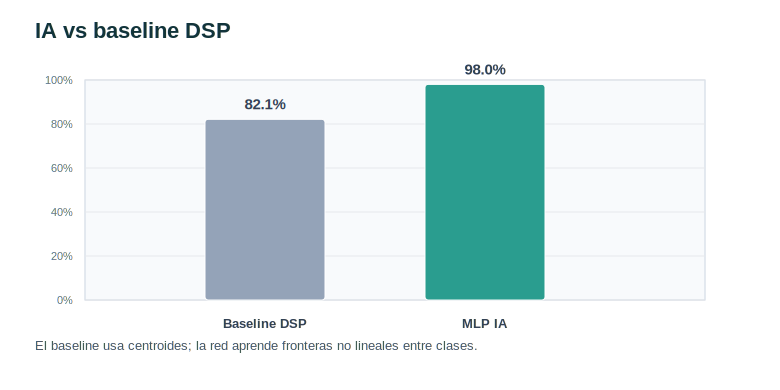

In [9]:
baseline_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="780" height="390" viewBox="0 0 780 390" style="background:#ffffff"><title>Baseline vs MLP</title><text x="35.0" y="38.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">IA vs baseline DSP</text><rect x="85.0" y="80.0" width="620.0" height="220.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="85.0" y1="300.0" x2="705.0" y2="300.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="304.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="85.0" y1="256.0" x2="705.0" y2="256.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="260.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="85.0" y1="212.0" x2="705.0" y2="212.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="216.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="85.0" y1="168.0" x2="705.0" y2="168.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="172.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="85.0" y1="124.0" x2="705.0" y2="124.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="128.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="85.0" y1="80.0" x2="705.0" y2="80.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="84.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><rect x="205.0" y="119.3" width="120.0" height="180.7" rx="3" fill="#94A3B8" stroke="#FFFFFF"/><text x="265.0" y="109.3" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">82.1%</text><text x="265.0" y="328.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="middle" fill="#334155">Baseline DSP</text><rect x="425.0" y="84.4" width="120.0" height="215.6" rx="3" fill="#2A9D8F" stroke="#FFFFFF"/><text x="485.0" y="74.4" font-family="Arial, sans-serif" font-size="15" font-weight="700" text-anchor="middle" fill="#334155">98.0%</text><text x="485.0" y="328.0" font-family="Arial, sans-serif" font-size="13" font-weight="700" text-anchor="middle" fill="#334155">MLP IA</text><text x="35.0" y="350.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">El baseline usa centroides; la red aprende fronteras no lineales entre clases.</text></svg>'
display(SVG(baseline_svg))


## 8. Validacion con multiples semillas

Una sola corrida puede depender de la particion de datos, de la inicializacion del modelo y de las senales generadas. Por eso se repite el experimento con cinco semillas. Este punto fortalece la defensa metodologica porque reporta estabilidad, no solamente un resultado favorable.


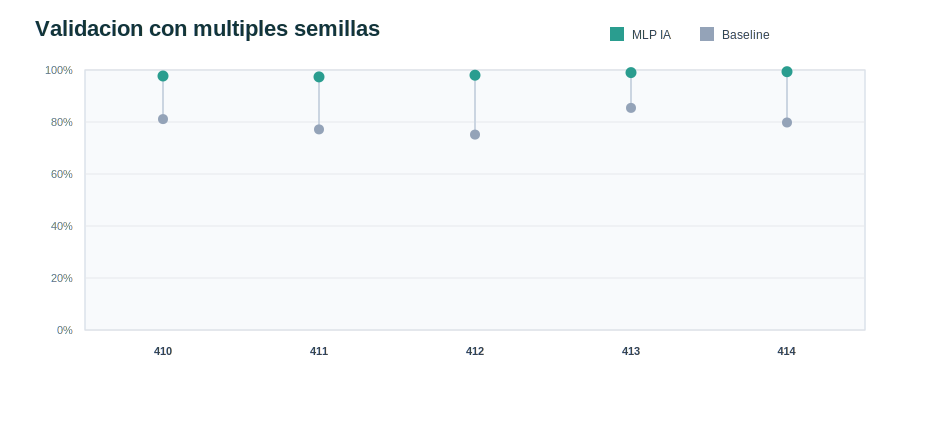

In [10]:
repeated_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="940" height="430" viewBox="0 0 940 430" style="background:#ffffff"><title>Validacion multisemilla</title><text x="35.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Validacion con multiples semillas</text><rect x="85.0" y="70.0" width="780.0" height="260.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="85.0" y1="330.0" x2="865.0" y2="330.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="334.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="85.0" y1="278.0" x2="865.0" y2="278.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="282.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="85.0" y1="226.0" x2="865.0" y2="226.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="230.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="85.0" y1="174.0" x2="865.0" y2="174.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="178.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="85.0" y1="122.0" x2="865.0" y2="122.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="126.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="85.0" y1="70.0" x2="865.0" y2="70.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="74.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><line x1="163.0" y1="119.1" x2="163.0" y2="76.0" stroke="#CBD5E1" stroke-width="2"/><circle cx="163.0" cy="119.1" r="5" fill="#94A3B8"/><circle cx="163.0" cy="76.0" r="5.5" fill="#2A9D8F"/><text x="163.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">410</text><line x1="319.0" y1="129.4" x2="319.0" y2="76.9" stroke="#CBD5E1" stroke-width="2"/><circle cx="319.0" cy="129.4" r="5" fill="#94A3B8"/><circle cx="319.0" cy="76.9" r="5.5" fill="#2A9D8F"/><text x="319.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">411</text><line x1="475.0" y1="134.6" x2="475.0" y2="75.2" stroke="#CBD5E1" stroke-width="2"/><circle cx="475.0" cy="134.6" r="5" fill="#94A3B8"/><circle cx="475.0" cy="75.2" r="5.5" fill="#2A9D8F"/><text x="475.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">412</text><line x1="631.0" y1="107.9" x2="631.0" y2="72.6" stroke="#CBD5E1" stroke-width="2"/><circle cx="631.0" cy="107.9" r="5" fill="#94A3B8"/><circle cx="631.0" cy="72.6" r="5.5" fill="#2A9D8F"/><text x="631.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">413</text><line x1="787.0" y1="122.5" x2="787.0" y2="71.7" stroke="#CBD5E1" stroke-width="2"/><circle cx="787.0" cy="122.5" r="5" fill="#94A3B8"/><circle cx="787.0" cy="71.7" r="5.5" fill="#2A9D8F"/><text x="787.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">414</text><rect x="610.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="632.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">MLP IA</text><rect x="700.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#94A3B8" stroke="none"/><text x="722.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Baseline</text></svg>'
display(SVG(repeated_svg))


En las cinco corridas, el MLP obtuvo **98.28% +/- 0.86%**. El baseline DSP obtuvo **79.74% +/- 3.93%**. La mejora media fue de **18.55 puntos porcentuales**.


## 9. Robustez ante SNR

El barrido por SNR mide que tan sensible es el clasificador al ruido. Esta prueba es esencial porque un sistema de comunicaciones real no trabaja siempre con senales limpias.


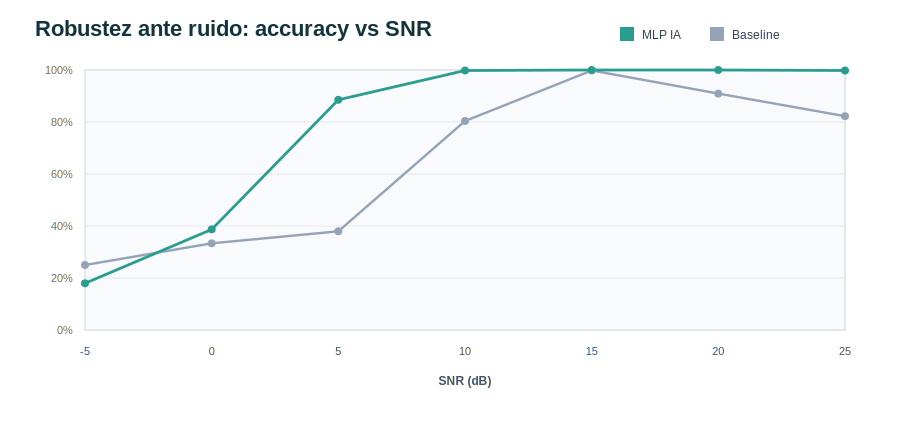

In [11]:
snr_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="920" height="430" viewBox="0 0 920 430" style="background:#ffffff"><title>Accuracy vs SNR</title><text x="35.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Robustez ante ruido: accuracy vs SNR</text><rect x="85.0" y="70.0" width="760.0" height="260.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="85.0" y1="330.0" x2="845.0" y2="330.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="334.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="85.0" y1="278.0" x2="845.0" y2="278.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="282.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="85.0" y1="226.0" x2="845.0" y2="226.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="230.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="85.0" y1="174.0" x2="845.0" y2="174.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="178.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="85.0" y1="122.0" x2="845.0" y2="122.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="126.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="85.0" y1="70.0" x2="845.0" y2="70.0" stroke="#E5E7EB" stroke-width="1"/><text x="73.0" y="74.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><polyline points="85.0,265.0 211.7,243.3 338.3,231.3 465.0,121.0 591.7,70.5 718.3,93.6 845.0,116.2" fill="none" stroke="#94A3B8" stroke-width="2.4" stroke-linejoin="round" stroke-linecap="round"/><polyline points="85.0,283.3 211.7,229.4 338.3,99.8 465.0,70.5 591.7,70.0 718.3,70.0 845.0,70.5" fill="none" stroke="#2A9D8F" stroke-width="2.8" stroke-linejoin="round" stroke-linecap="round"/><circle cx="85.0" cy="265.0" r="4" fill="#94A3B8"/><circle cx="85.0" cy="283.3" r="4" fill="#2A9D8F"/><text x="85.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">-5</text><circle cx="211.7" cy="243.3" r="4" fill="#94A3B8"/><circle cx="211.7" cy="229.4" r="4" fill="#2A9D8F"/><text x="211.7" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">0</text><circle cx="338.3" cy="231.3" r="4" fill="#94A3B8"/><circle cx="338.3" cy="99.8" r="4" fill="#2A9D8F"/><text x="338.3" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">5</text><circle cx="465.0" cy="121.0" r="4" fill="#94A3B8"/><circle cx="465.0" cy="70.5" r="4" fill="#2A9D8F"/><text x="465.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">10</text><circle cx="591.7" cy="70.5" r="4" fill="#94A3B8"/><circle cx="591.7" cy="70.0" r="4" fill="#2A9D8F"/><text x="591.7" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">15</text><circle cx="718.3" cy="93.6" r="4" fill="#94A3B8"/><circle cx="718.3" cy="70.0" r="4" fill="#2A9D8F"/><text x="718.3" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">20</text><circle cx="845.0" cy="116.2" r="4" fill="#94A3B8"/><circle cx="845.0" cy="70.5" r="4" fill="#2A9D8F"/><text x="845.0" y="355.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="middle" fill="#475569">25</text><text x="465.0" y="385.0" font-family="Arial, sans-serif" font-size="12" font-weight="700" text-anchor="middle" fill="#475569">SNR (dB)</text><rect x="620.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="642.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">MLP IA</text><rect x="710.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#94A3B8" stroke="none"/><text x="732.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Baseline</text></svg>'
display(SVG(snr_svg))


## 10. Ablation study

El ablation study entrena y evalua modelos usando grupos de rasgos por separado. Su funcion no es solo mejorar accuracy, sino explicar que informacion DSP es mas discriminante.


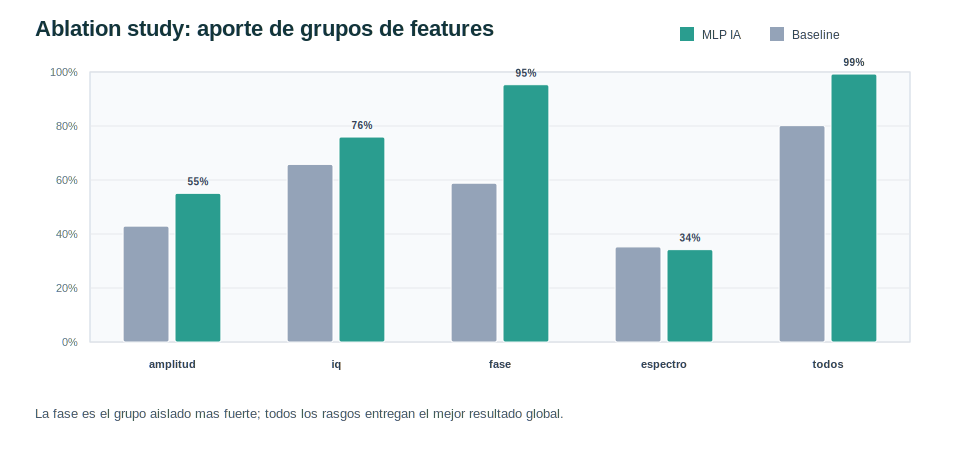

In [12]:
ablation_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="980" height="470" viewBox="0 0 980 470" style="background:#ffffff"><title>Ablation study: aporte de grupos de features</title><text x="35.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Ablation study: aporte de grupos de features</text><rect x="90.0" y="72.0" width="820.0" height="270.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="90.0" y1="342.0" x2="910.0" y2="342.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="346.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="90.0" y1="288.0" x2="910.0" y2="288.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="292.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="90.0" y1="234.0" x2="910.0" y2="234.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="238.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="90.0" y1="180.0" x2="910.0" y2="180.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="184.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="90.0" y1="126.0" x2="910.0" y2="126.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="130.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="90.0" y1="72.0" x2="910.0" y2="72.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="76.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><rect x="123.1" y="226.1" width="45.9" height="115.9" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="175.0" y="193.3" width="45.9" height="148.7" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="172.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">amplitud</text><text x="198.0" y="185.3" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">55%</text><rect x="287.1" y="164.4" width="45.9" height="177.6" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="339.0" y="137.0" width="45.9" height="205.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="336.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">iq</text><text x="362.0" y="129.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">76%</text><rect x="451.1" y="183.2" width="45.9" height="158.8" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="503.0" y="84.7" width="45.9" height="257.3" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="500.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">fase</text><text x="526.0" y="76.7" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">95%</text><rect x="615.1" y="246.9" width="45.9" height="95.1" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="667.0" y="249.6" width="45.9" height="92.4" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="664.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">espectro</text><text x="690.0" y="241.6" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">34%</text><rect x="779.1" y="125.6" width="45.9" height="216.4" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="831.0" y="74.0" width="45.9" height="268.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="828.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">todos</text><text x="854.0" y="66.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">99%</text><rect x="680.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="702.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">MLP IA</text><rect x="770.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#94A3B8" stroke="none"/><text x="792.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Baseline</text><text x="35.0" y="418.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">La fase es el grupo aislado mas fuerte; todos los rasgos entregan el mejor resultado global.</text></svg>'
display(SVG(ablation_svg))


## 11. Generalizacion a canales no ideales

El modelo se entrena con AWGN y luego se prueba en AWGN, Rayleigh y multipath. Si el rendimiento cae mucho en un canal nuevo, eso revela una limitacion realista y una linea de mejora.


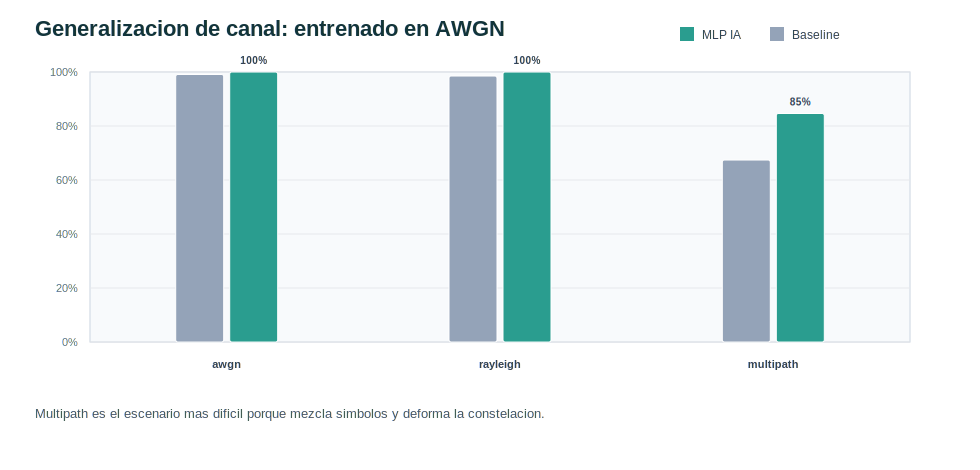

In [13]:
channel_svg = '<svg xmlns="http://www.w3.org/2000/svg" width="980" height="470" viewBox="0 0 980 470" style="background:#ffffff"><title>Generalizacion de canal: entrenado en AWGN</title><text x="35.0" y="36.0" font-family="Arial, sans-serif" font-size="22" font-weight="700" text-anchor="start" fill="#12343B">Generalizacion de canal: entrenado en AWGN</text><rect x="90.0" y="72.0" width="820.0" height="270.0" rx="0" fill="#F8FAFC" stroke="#CBD5E1"/><line x1="90.0" y1="342.0" x2="910.0" y2="342.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="346.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">0%</text><line x1="90.0" y1="288.0" x2="910.0" y2="288.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="292.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">20%</text><line x1="90.0" y1="234.0" x2="910.0" y2="234.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="238.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">40%</text><line x1="90.0" y1="180.0" x2="910.0" y2="180.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="184.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">60%</text><line x1="90.0" y1="126.0" x2="910.0" y2="126.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="130.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">80%</text><line x1="90.0" y1="72.0" x2="910.0" y2="72.0" stroke="#E5E7EB" stroke-width="1"/><text x="78.0" y="76.0" font-family="Arial, sans-serif" font-size="11" font-weight="400" text-anchor="end" fill="#64748B">100%</text><rect x="175.7" y="74.5" width="48.0" height="267.5" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="229.7" y="72.0" width="48.0" height="270.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="226.7" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">awgn</text><text x="253.7" y="64.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">100%</text><rect x="449.0" y="76.0" width="48.0" height="266.0" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="503.0" y="72.0" width="48.0" height="270.0" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="500.0" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">rayleigh</text><text x="527.0" y="64.0" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">100%</text><rect x="722.3" y="160.0" width="48.0" height="182.0" rx="2" fill="#94A3B8" stroke="#FFFFFF"/><rect x="776.3" y="113.5" width="48.0" height="228.5" rx="2" fill="#2A9D8F" stroke="#FFFFFF"/><text x="773.3" y="368.0" font-family="Arial, sans-serif" font-size="11" font-weight="700" text-anchor="middle" fill="#334155">multipath</text><text x="800.3" y="105.5" font-family="Arial, sans-serif" font-size="10" font-weight="700" text-anchor="middle" fill="#334155">85%</text><rect x="680.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#2A9D8F" stroke="none"/><text x="702.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">MLP IA</text><rect x="770.0" y="27.0" width="14.0" height="14.0" rx="0" fill="#94A3B8" stroke="none"/><text x="792.0" y="39.0" font-family="Arial, sans-serif" font-size="12" font-weight="400" text-anchor="start" fill="#334155">Baseline</text><text x="35.0" y="418.0" font-family="Arial, sans-serif" font-size="13" font-weight="400" text-anchor="start" fill="#475569">Multipath es el escenario mas dificil porque mezcla simbolos y deforma la constelacion.</text></svg>'
display(SVG(channel_svg))


## 12. Interpretacion investigativa

Los resultados apoyan la hipotesis: los rasgos DSP contienen informacion suficiente para clasificar modulaciones con un modelo ligero. El MLP supera claramente al baseline de centroides, mantiene buen rendimiento en multiples semillas y muestra alta robustez desde SNR moderados.

La parte mas importante para investigacion es que el proyecto no termina en "accuracy alto". Tambien analiza estabilidad, ruido, aportes de features y cambio de canal. Eso lo hace defendible como propuesta, no solo como demo de codigo.


## 13. Extensiones inmediatas

Las siguientes extensiones ya quedan planteadas como continuidad natural del trabajo:

1. **Espectrogramas como imagenes:** convertir la senal IQ a representaciones tiempo-frecuencia y entrenar un modelo tipo CNN.
2. **Clasificador basado en reglas:** construir reglas DSP simples para comparar contra el MLP y contra el baseline de centroides.
3. **Mayor robustez por SNR:** repetir el barrido con mas semillas y reportar media/desviacion por cada nivel de ruido.
4. **Canales Rayleigh/Rician:** incluir fading con y sin componente dominante de linea de vista para acercar el simulador a escenarios reales.

Estas extensiones no sustituyen el proyecto actual; lo vuelven mas fuerte porque agregan comparacion, vision tiempo-frecuencia y canales mas realistas.


## 14. Conclusiones

El sistema demuestra que se puede hacer reconocimiento automatico de modulaciones con una arquitectura ligera y reproducible. La combinacion de DSP e IA es adecuada porque el DSP resume la senal en rasgos interpretables y la red neuronal aprende relaciones no lineales entre esos rasgos.

Una formulacion fuerte para defender el proyecto seria:

**Evaluacion de robustez y explicabilidad de un clasificador inteligente de modulaciones digitales basado en rasgos DSP bajo condiciones de canal no ideales.**
